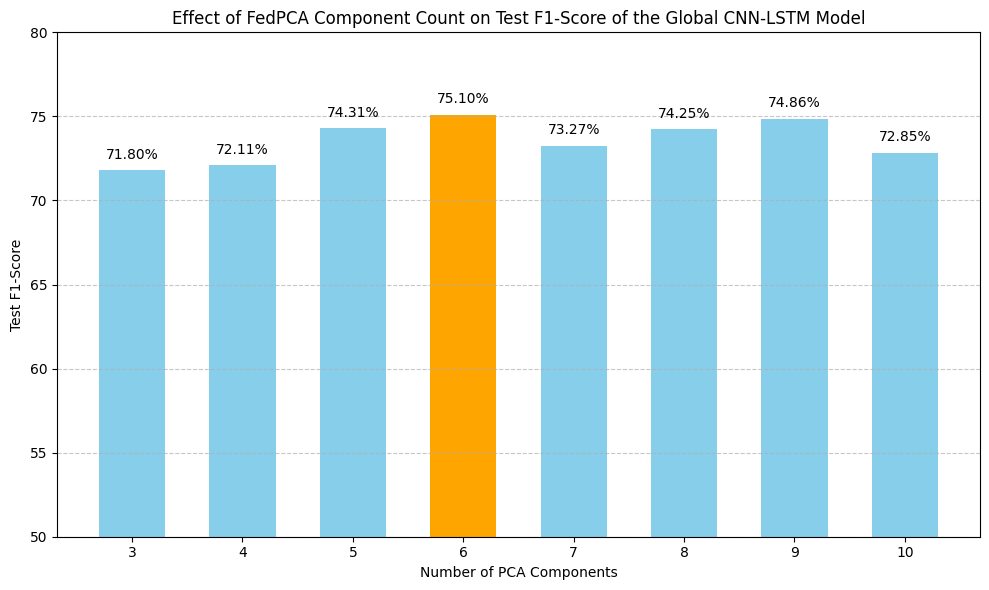

In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# Results: Test F1-score for varying FedPCA component counts
components = [3, 4, 5, 6, 7, 8, 9, 10]
f1_scores = [71.80222, 72.10722, 74.31399, 75.10106,
             73.26884, 74.25024, 74.86339, 72.84587]

# Identify the index of the maximum score
max_idx = np.argmax(f1_scores)

# Generate a color list that highlights the max bar
colors = ['skyblue'] * len(components)
colors[max_idx] = 'orange'

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(components, f1_scores, width=0.6, color=colors)

# Annotate each bar with its value
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{score:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Set x-axis ticks at every 2 components
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.set_xticks(components)

# Adjust y-axis limits for clarity
ax.set_ylim(50, 80)

# Labels and title
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Test F1-Score')
ax.set_title('Effect of FedPCA Component Count on Test F1-Score of the Global CNN-LSTM Model')

# Optional: remove legend since coloring is self-explanatory
# ax.legend()

ax.grid(axis='y', linestyle='--', alpha=0.7)
fig.tight_layout()
plt.show()

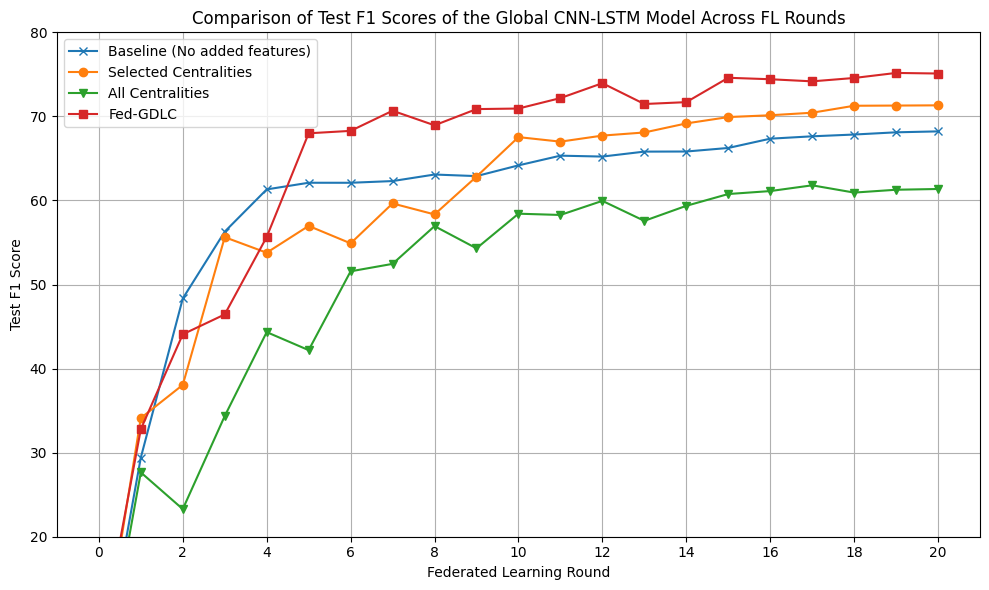

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Load the experiment results
df = pd.read_csv('results\\wandb_export_2025-06-25T12_12_38.655+02_00.csv')

# Prepare the plot
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(df['round'], df['baseline_cnn_lstm_test - test_f1'],
         marker='x', label='Baseline (No added features)')
plt.plot(df['round'], df['selected_centralities_cnn_lstm_test - test_f1'],
         marker='o', label='Selected Centralities')
plt.plot(df['round'], df['all_centralities_cnn_lstm_test - test_f1'],
         marker='v', label='All Centralities')
plt.plot(df['round'], df['pca_gdlc_cnn_lstm_test - test_f1'],
         marker='s', label='Fed-GDLC')

# Set x-axis ticks at every 2 rounds
ax.xaxis.set_major_locator(MultipleLocator(2))

ax.set_ylim(20, 80)
# Labels and legend
ax.set_xlabel('Federated Learning Round')
ax.set_ylabel('Test F1 Score')
ax.set_title('Comparison of Test F1 Scores of the Global CNN-LSTM Model Across FL Rounds')
ax.legend()
ax.grid(True)
fig.tight_layout()

# Display the plot
plt.show()

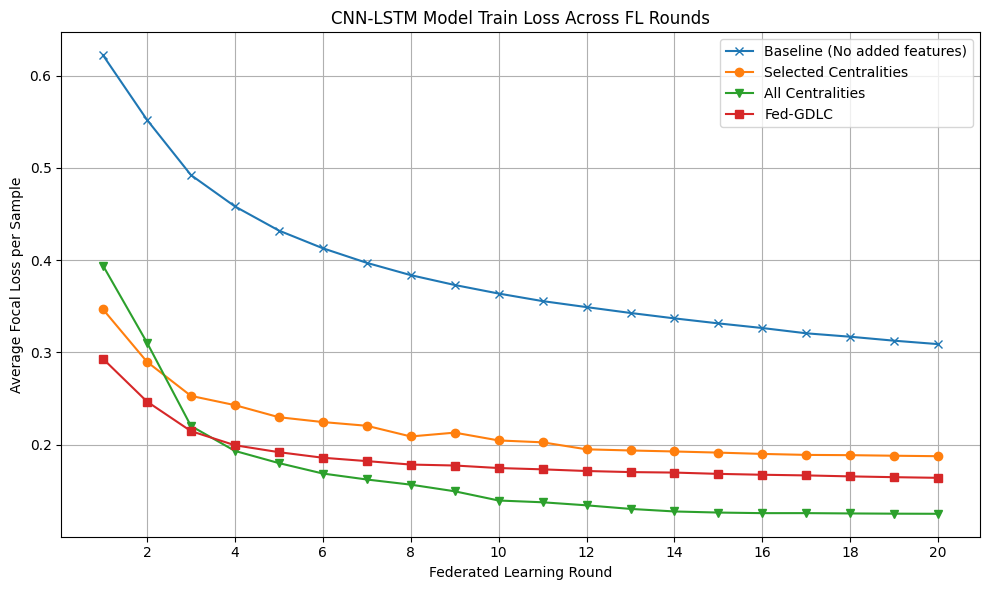

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

df_loss = pd.read_csv(
    'results\\wandb_export_2025-06-25T12_12_31.570+02_00.csv')

# Batch size used
batch_size = 2048

# Columns to convert to per-sample loss
cols = {
    'Baseline': 'baseline_cnn_lstm_test - train_loss_avg',
    'Selected Centralities': 'selected_centralities_cnn_lstm_test - train_loss_avg',
    'All Centralities': 'all_centralities_cnn_lstm_test - train_loss_avg',
    'PCA + GDLC': 'pca_gdlc_cnn_lstm_test - train_loss_avg'
}

# Compute per-sample loss
for label, col in cols.items():
    df_loss[f'{label} per_sample'] = df_loss[col] / batch_size

# Plot per-sample train loss
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(df_loss['round'], df_loss['Baseline per_sample'],
         marker='x', label='Baseline (No added features)')
plt.plot(df_loss['round'], df_loss['Selected Centralities per_sample'],
         marker='o', label='Selected Centralities')
plt.plot(df_loss['round'], df_loss['All Centralities per_sample'],
         marker='v', label='All Centralities')
plt.plot(df_loss['round'], df_loss['PCA + GDLC per_sample'],
         marker='s', label='Fed-GDLC')

# for label in cols.keys():
#     print(f'{label} per_sample')
#     ax.plot(
#         df_loss['round'],
#         df_loss[f'{label} per_sample'],
#         marker='o',
#         label=label
#     )

# Set x-axis ticks every 2 rounds
ax.xaxis.set_major_locator(MultipleLocator(2))

# Labels and legend
ax.set_xlabel('Federated Learning Round')
ax.set_ylabel('Average Focal Loss per Sample')
ax.set_title('CNN-LSTM Model Train Loss Across FL Rounds')
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

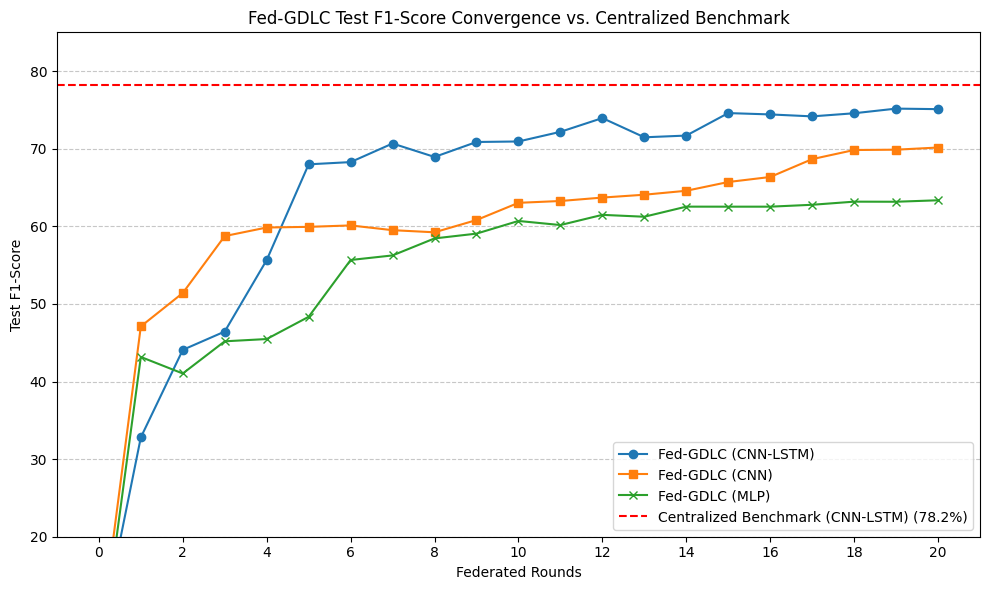

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# Example data (replace with your actual F1-score lists)
rounds = np.arange(0, 21)
f1_cnn_lstm = [6.026376724, 32.79651642, 44.07958221, 46.44252777, 55.65638351, 67.98983002, 68.27806854, 70.67347717, 68.94070435, 70.8690567,
               70.93527222, 72.17815399, 73.95108795, 71.47354889, 71.69580841, 74.59397888, 74.41996002, 74.16934204, 74.57097626, 75.16973114, 75.10105896]
f1_cnn = [5.477581024, 47.10118866, 51.40731049, 58.74365997, 59.84780502, 59.93235016, 60.11639404, 59.50431061, 59.23058319, 60.80945969,
          63.02909851, 63.2641716, 63.70547867, 64.07353592, 64.58214951, 65.71148682, 66.35855103, 68.66036224, 69.83387756, 69.87702179, 70.15571899]

f1_mlp = [2.956079483, 43.16662979, 41.03559113, 45.18306732, 45.47484207, 48.34237289, 55.66196442, 56.25111771, 58.44221497, 59.05924225,
          60.69233704, 60.16457748, 61.47885895, 61.23564529, 62.53686905, 62.53308868, 62.53318787, 62.77758026, 63.17904663, 63.16817474, 63.35737228]

centralized_f1 = 78.27336  # Centralized model final F1-score

fig, ax = plt.subplots(figsize=(10, 6))

# Plot Fed-GDLC convergence curves
ax.plot(rounds, f1_cnn_lstm, marker='o',
        linestyle='-', label='Fed-GDLC (CNN-LSTM)')
ax.plot(rounds, f1_cnn,      marker='s',
        linestyle='-', label='Fed-GDLC (CNN)')
ax.plot(rounds, f1_mlp,      marker='x',
        linestyle='-', label='Fed-GDLC (MLP)')

# Plot centralized benchmark line
ax.axhline(y=centralized_f1, color='red', linestyle='--',
           label='Centralized Benchmark (CNN-LSTM) (78.2%)')
ax.xaxis.set_major_locator(MultipleLocator(2))

# Axis formatting
ax.set_xlabel('Federated Rounds')
ax.set_ylabel('Test F1-Score')
ax.set_title('Fed-GDLC Test F1-Score Convergence vs. Centralized Benchmark')
ax.set_ylim(20, 85)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Legend and layout
ax.legend()
plt.tight_layout()
plt.show()